In [5]:
import pandas as pd

In [52]:
df = pd.read_csv ("World-Stock-Prices-Dataset.csv")

In [54]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2025-05-16 00:00:00-04:00,6.320000,6.435000,6.220000,6.340000,12457200.0,0.0,0.0,peloton,PTON,fitness,usa,NaN
1,2025-05-16 00:00:00-04:00,118.070000,118.239998,116.010002,117.169998,42968300.0,0.0,0.0,amd,AMD,technology,usa,NaN
2,2025-05-16 00:00:00-04:00,121.620003,124.180000,121.620003,124.010002,34100.0,0.0,0.0,adidas,ADDYY,apparel,germany,NaN
3,2025-05-16 00:00:00-04:00,300.359985,301.649994,297.829987,299.720001,2959400.0,0.0,0.0,american express,AXP,finance,usa,NaN
4,2025-05-16 00:00:00-04:00,25.545000,25.545000,25.545000,25.545000,0.0,0.0,0.0,puma,PMMAF,apparel,germany,NaN


In [56]:
df.shape

(307735, 13)

In [58]:
df.describe

<bound method NDFrame.describe of                              Date        Open        High         Low  \
0       2025-05-16 00:00:00-04:00    6.320000    6.435000    6.220000   
1       2025-05-16 00:00:00-04:00  118.070000  118.239998  116.010002   
2       2025-05-16 00:00:00-04:00  121.620003  124.180000  121.620003   
3       2025-05-16 00:00:00-04:00  300.359985  301.649994  297.829987   
4       2025-05-16 00:00:00-04:00   25.545000   25.545000   25.545000   
...                           ...         ...         ...         ...   
307730  2000-01-03 00:00:00-05:00    2.360523    2.440855    2.298729   
307731  2000-01-03 00:00:00-05:00   24.863424   25.071313   23.990294   
307732  2000-01-03 00:00:00-05:00    2.647906    2.659888    2.611962   
307733  2000-01-03 00:00:00-05:00   22.631671   23.163612   22.244805   
307734  2000-01-03 00:00:00-05:00    5.731675    5.793975    5.427959   

             Close      Volume  Dividends  Stock Splits  \
0         6.340000  12457200.0

In [60]:
df = df.sort_values('Date').reset_index(drop=True)


In [62]:
# Check if dates are sorted
is_sorted = df['Date'].is_monotonic_increasing

# Output results
print("✅ Date Format (after conversion):", df['Date'].dtype)
print("📅 Are dates sorted chronologically?", is_sorted)

# Optional: show first and last date
print("🔽 Start Date:", df['Date'].min())
print("🔼 End Date:", df['Date'].max())

✅ Date Format (after conversion): object
📅 Are dates sorted chronologically? True
🔽 Start Date: 2000-01-03 00:00:00-05:00
🔼 End Date: 2025-05-16 00:00:00-04:00


In [64]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2000-01-03 00:00:00-05:00,5.731675,5.793975,5.427959,5.482471,5825700.0,0.0,0.0,american eagle outfitters,AEO,apparel,usa,NaN
1,2000-01-03 00:00:00-05:00,11.826695,11.850113,11.405149,11.428568,2506717.0,0.0,0.0,marriott,MAR,hospitality,usa,NaN
2,2000-01-03 00:00:00-05:00,22.361069,22.431057,21.801168,22.186100,4520600.0,0.0,0.0,mcdonald's,MCD,food,usa,NaN
3,2000-01-03 00:00:00-05:00,34.729481,34.729481,32.934947,33.198849,6471267.0,0.0,0.0,american express,AXP,finance,usa,NaN
4,2000-01-03 00:00:00-05:00,35.788786,36.844503,34.627498,36.263859,1734000.0,0.0,0.0,fedex,FDX,logistics,usa,NaN


In [66]:
# Display unique stock count
unique_stocks = df['Brand_Name'].nunique()  # Change 'Name' if the column is called something else
print("📈 Number of unique stocks in dataset:", unique_stocks)

📈 Number of unique stocks in dataset: 61


In [68]:
print(df['Brand_Name'].unique()[:61])  # Show a sample


['american eagle outfitters' 'marriott' "mcdonald's" 'american express'
 'fedex' 'apple' 'the coca-cola company' 'amazon' 'unilever' 'microsoft'
 'amd' 'nike' 'hershey company' 'nvidia' 'adobe' 'target'
 'southwest airlines' 'the walt disney company' 'philips' 'logitech'
 'jpmorgan chase & co' 'starbucks' 'colgate palmolive' 'johnson & johnson'
 'foot locker' 'procter & gamble' 'the home depot' 'costco' 'cisco' '3m'
 'toyota' 'nordstrom' 'honda' 'nintendo' 'netflix' 'salesforce / slack'
 'google' 'chipotle' 'lvmh' 'crocs' 'mastercard' 'adidas'
 'delta air lines' 'visa' 'bmw group' 'porsche' 'ubisoft' 'tesla' 'puma'
 'hilton' 'shopify' 'block' 'spotify' 'pinterest'
 'zoom video communications' 'uber' 'peloton' 'zoominfo' 'airbnb' 'roblox'
 'coinbase']


In [70]:
# Preview column names to ensure correct references
print("📋 Columns:", df.columns)

# STEP 1: Group by 'Name' or 'Symbol' to count records (popularity by frequency)
stock_freq = df['Brand_Name'].value_counts().head(10)
print("\n🔥 Top 10 Stocks by Record Count (Frequency):")
print(stock_freq)

# STEP 2: Group by 'Name' and sum up 'Volume' (popularity by trading volume)
stock_volume = df.groupby('Brand_Name')['Volume'].sum().sort_values(ascending=False).head(10)
print("\n💰 Top 10 Stocks by Total Trading Volume:")
print(stock_volume)

📋 Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits', 'Brand_Name', 'Ticker', 'Industry_Tag', 'Country',
       'Capital Gains'],
      dtype='object')

🔥 Top 10 Stocks by Record Count (Frequency):
Brand_Name
marriott                   6430
nvidia                     6429
johnson & johnson          6429
costco                     6429
starbucks                  6429
jpmorgan chase & co        6429
cisco                      6429
3m                         6429
the walt disney company    6429
southwest airlines         6429
Name: count, dtype: int64

💰 Top 10 Stocks by Total Trading Volume:
Brand_Name
apple                    2.435087e+12
amazon                   7.517005e+11
google                   5.970986e+11
nvidia                   5.359885e+11
tesla                    3.675006e+11
microsoft                3.176582e+11
cisco                    2.690458e+11
amd                      2.181192e+11
jpmorgan chase & co      1.245353e+11


In [72]:
# Define the list of selected stock names
selected_stocks = [
    "apple", "amazon", "google", "nvidia", "tesla",
    "microsoft", "nike", "american express", "McDonald's", "netflix"
]

# Filter the dataset for only those stocks
filtered_df = df[df['Brand_Name'].isin(selected_stocks)]

# Confirm how many records are available per selected stock
stock_counts = filtered_df['Brand_Name'].value_counts()

print("✅ Selected Stocks Found and Their Record Counts:")
print(stock_counts)

# Optional: Save filtered dataset for further modeling
filtered_df.to_csv("filtered_10_stocks.csv", index=False)

✅ Selected Stocks Found and Their Record Counts:
Brand_Name
american express    6429
apple               6429
amazon              6429
microsoft           6429
nike                6429
nvidia              6429
netflix             5831
google              5267
tesla               3792
Name: count, dtype: int64


In [74]:
df = pd.read_csv ("filtered_10_stocks.csv")

In [76]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2000-01-03 00:00:00-05:00,34.729481,34.729481,32.934947,33.198849,6471267.0,0.0,0.0,american express,AXP,finance,usa,NaN
1,2000-01-03 00:00:00-05:00,0.794800,0.852586,0.770643,0.848323,535796800.0,0.0,0.0,apple,AAPL,technology,usa,NaN
2,2000-01-03 00:00:00-05:00,4.075000,4.478125,3.952344,4.468750,322352000.0,0.0,0.0,amazon,AMZN,e-commerce,usa,NaN
3,2000-01-03 00:00:00-05:00,36.457976,36.846240,34.788441,36.205605,53228400.0,0.0,0.0,microsoft,MSFT,technology,usa,NaN
4,2000-01-03 00:00:00-05:00,4.785835,4.810098,4.634192,4.670587,8014400.0,0.0,0.0,nike,NKE,apparel,usa,NaN


In [78]:
df.shape

(53464, 13)

In [88]:
# Display total missing values per column
print("🔍 Missing values per column:")
print(df.isnull().sum())

# Optional: Show columns with missing values only
missing_cols = df.columns[df.isnull().any()]
print("\n📋 Columns with missing values:")
print(missing_cols)

# Optional: Show percentage of missing values
print("\n📊 Percentage of missing values:")
print((df.isnull().mean() * 100).round(2))

🔍 Missing values per column:
Date                 0
Open                 0
High                 0
Low                  0
Close                0
Volume               0
Dividends            0
Stock Splits         0
Brand_Name           0
Ticker               0
Industry_Tag         0
Country              0
Capital Gains    53464
dtype: int64

📋 Columns with missing values:
Index(['Capital Gains'], dtype='object')

📊 Percentage of missing values:
Date               0.0
Open               0.0
High               0.0
Low                0.0
Close              0.0
Volume             0.0
Dividends          0.0
Stock Splits       0.0
Brand_Name         0.0
Ticker             0.0
Industry_Tag       0.0
Country            0.0
Capital Gains    100.0
dtype: float64


In [90]:
df = df.drop(columns=['Capital Gains'])


In [92]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country
0,2000-01-03 00:00:00-05:00,34.729481,34.729481,32.934947,33.198849,6471267.0,0.0,0.0,american express,AXP,finance,usa
1,2000-01-03 00:00:00-05:00,0.794800,0.852586,0.770643,0.848323,535796800.0,0.0,0.0,apple,AAPL,technology,usa
2,2000-01-03 00:00:00-05:00,4.075000,4.478125,3.952344,4.468750,322352000.0,0.0,0.0,amazon,AMZN,e-commerce,usa
3,2000-01-03 00:00:00-05:00,36.457976,36.846240,34.788441,36.205605,53228400.0,0.0,0.0,microsoft,MSFT,technology,usa
4,2000-01-03 00:00:00-05:00,4.785835,4.810098,4.634192,4.670587,8014400.0,0.0,0.0,nike,NKE,apparel,usa


In [94]:
df.shape

(53464, 12)

In [96]:
# Check for negative or zero values in price columns
price_columns = ['Open', 'High', 'Low', 'Close']

for col in price_columns:
    invalid = df[df[col] <= 0]
    print(f"\n⚠️ Entries with non-positive values in '{col}': {len(invalid)}")
    if not invalid.empty:
        print(invalid[['Date', 'Ticker', col]].head())



⚠️ Entries with non-positive values in 'Open': 0

⚠️ Entries with non-positive values in 'High': 0

⚠️ Entries with non-positive values in 'Low': 0

⚠️ Entries with non-positive values in 'Close': 0


In [120]:
# Convert and clean Date
df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df = df.dropna(subset=['Date']).sort_values(['Brand_Name', 'Date']).reset_index(drop=True)

# Define list of selected stocks
selected_stocks = [
    "apple", "amazon", "google", "nvidia", "tesla",
    "microsoft", "nike", "american express", "McDonald's", "netflix"
]

# Empty list to hold processed stock DataFrames
processed_stocks = []

# Loop through each stock
for stock in selected_stocks:
    stock_df = df[df['Brand_Name'] == stock].copy()
    stock_df = stock_df.sort_values('Date').reset_index(drop=True)

    # ========== FEATURE ENGINEERING ==========
    # Lag features
    stock_df['Close_lag1'] = stock_df['Close'].shift(1)
    stock_df['Close_lag2'] = stock_df['Close'].shift(2)
    stock_df['Volume_lag1'] = stock_df['Volume'].shift(1)

    # Rolling stats
    stock_df['Close_roll_mean_5'] = stock_df['Close'].rolling(window=5).mean()
    stock_df['Close_roll_std_5'] = stock_df['Close'].rolling(window=5).std()
    
    # RSI
    delta = stock_df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    stock_df['RSI_14'] = 100 - (100 / (1 + rs))

    # EMA & MACD
    ema12 = stock_df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = stock_df['Close'].ewm(span=26, adjust=False).mean()
    stock_df['MACD'] = ema12 - ema26
    stock_df['EMA_10'] = stock_df['Close'].ewm(span=10, adjust=False).mean()

    # Time-based features
    stock_df['Day_of_Week'] = stock_df['Date'].dt.dayofweek
    stock_df['Month'] = stock_df['Date'].dt.month
    stock_df['Is_Month_End'] = stock_df['Date'].dt.is_month_end.astype(int)

    # Drop rows with NaNs due to shifting and rolling
    stock_df = stock_df.dropna().reset_index(drop=True)

    # Append processed DataFrame
    processed_stocks.append(stock_df)

# Combine all stocks into one final DataFrame
df = pd.concat(processed_stocks, ignore_index=True)

# Optional: Save to CSV
#final_df.to_csv("engineered_10_stocks.csv", index=False)

print("✅ Feature engineering completed for all 10 stocks. Final dataset shape:", final_df.shape)

✅ Feature engineering completed for all 10 stocks. Final dataset shape: (53338, 25)


In [124]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,...,Volume_lag1,Close_roll_mean_5,Close_roll_std_5,Volume_roll_mean_10,RSI_14,MACD,EMA_10,Day_of_Week,Month,Is_Month_End
0,2000-01-24 05:00:00+00:00,0.821798,0.854480,0.796694,0.805220,440876800.0,0.0,0.0,apple,AAPL,...,495924800.0,0.820851,0.029925,190462699.8,45.955568,-0.006560,0.796434,0,1,0
1,2000-01-25 05:00:00+00:00,0.795747,0.857323,0.775853,0.850691,497145600.0,0.0,0.0,apple,AAPL,...,440876800.0,0.833450,0.025394,190311611.0,57.289669,-0.001599,0.806299,1,1,0
2,2000-01-26 05:00:00+00:00,0.833639,0.865374,0.831745,0.835060,367158400.0,0.0,0.0,apple,AAPL,...,497145600.0,0.838944,0.020989,106050762.4,54.587612,0.001059,0.811528,2,1,0
3,2000-01-27 05:00:00+00:00,0.824640,0.856376,0.810904,0.833640,340144000.0,0.0,0.0,apple,AAPL,...,367158400.0,0.833640,0.017316,115871930.9,62.793235,0.003016,0.815549,3,1,0
4,2000-01-28 05:00:00+00:00,0.819903,0.840270,0.762591,0.770169,423348800.0,0.0,0.0,apple,AAPL,...,340144000.0,0.818956,0.031823,116311441.8,51.699966,-0.000548,0.807298,4,1,0


In [130]:
# Define the target variable: next day's Close price, per stock
df['Target'] = df.groupby('Brand_Name')['Close'].shift(-1)

# Drop rows where the target is NaN (last row of each stock group)
df = df.dropna(subset=['Target']).reset_index(drop=True)

# Confirm it's been added
print("✅ Target column added successfully.")
print("📊 Final dataset shape:", df.shape)
print(df[['Brand_Name', 'Date', 'Close', 'Target']].head())


✅ Target column added successfully.
📊 Final dataset shape: (53329, 26)
  Brand_Name                      Date     Close    Target
0      apple 2000-01-24 05:00:00+00:00  0.805220  0.850691
1      apple 2000-01-25 05:00:00+00:00  0.850691  0.835060
2      apple 2000-01-26 05:00:00+00:00  0.835060  0.833640
3      apple 2000-01-27 05:00:00+00:00  0.833640  0.770169
4      apple 2000-01-28 05:00:00+00:00  0.770169  0.786273


In [132]:
df = df.sort_values('Date').reset_index(drop=True)


In [136]:
# STEP 1: Define features and target
drop_cols = ['Date', 'Ticker', 'Target']  # Columns to drop
features = [col for col in df.columns if col not in drop_cols]

# STEP 2: Split the full dataset by time
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# STEP 3: Create input (X) and output (y) sets
X_train = train_df[features]
y_train = train_df['Target']

X_test = test_df[features]
y_test = test_df['Target']

# STEP 4: Confirm shapes
print("✅ X_train:", X_train.shape)
print("✅ y_train:", y_train.shape)
print("✅ X_test:", X_test.shape)
print("✅ y_test:", y_test.shape)


✅ X_train: (42663, 23)
✅ y_train: (42663,)
✅ X_test: (10666, 23)
✅ y_test: (10666,)


In [140]:
# List of non-numeric or non-useful columns
non_numeric_cols = ['Date', 'Ticker', 'Brand_Name', 'Industry_Tag', 'Country']
drop_cols = non_numeric_cols + ['Target']

# Define features (only numeric columns)
features = [col for col in final_df.columns if col not in drop_cols]

# Split again with cleaned features
X_train = train_df[features]
y_train = train_df['Target']

X_test = test_df[features]
y_test = test_df['Target']


In [142]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Support Vector Regressor": SVR(),
    "KNN Regressor": KNeighborsRegressor(),
    "MLP Regressor": MLPRegressor(max_iter=500, random_state=42)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"🔄 Training: {name}")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append((name, mae, rmse, r2))

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2_Score'])
results_df = results_df.sort_values(by='R2_Score', ascending=False)

print("\n📊 Model Performance Summary:")
print(results_df)


🔄 Training: Linear Regression
🔄 Training: Ridge Regression
🔄 Training: Lasso Regression


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=6.10537e-21): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.098e+05, tolerance: 1.252e+04
  model = cd_fast.enet_coordinate_descent(


🔄 Training: ElasticNet


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.091e+04, tolerance: 1.252e+04
  model = cd_fast.enet_coordinate_descent(


🔄 Training: Decision Tree
🔄 Training: Random Forest
🔄 Training: Extra Trees
🔄 Training: XGBoost
🔄 Training: LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3900
[LightGBM] [Info] Number of data points in the train set: 42663, number of used features: 19
[LightGBM] [Info] Start training from score 34.114892
🔄 Training: Support Vector Regressor
🔄 Training: KNN Regressor
🔄 Training: MLP Regressor

📊 Model Performance Summary:
                       Model           MAE           RMSE       R2_Score
1           Ridge Regression      3.827710       7.610056       0.997503
0          Linear Regression      3.827742       7.610103       0.997503
3                 ElasticNet      4.338782       8.130026 

C:\Users\HP\AppData\Local\Temp\ipykernel_20840\3466330885.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20840\3466330885.py:17: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.savefig("model_performance_bar_chart.png", dpi=300)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


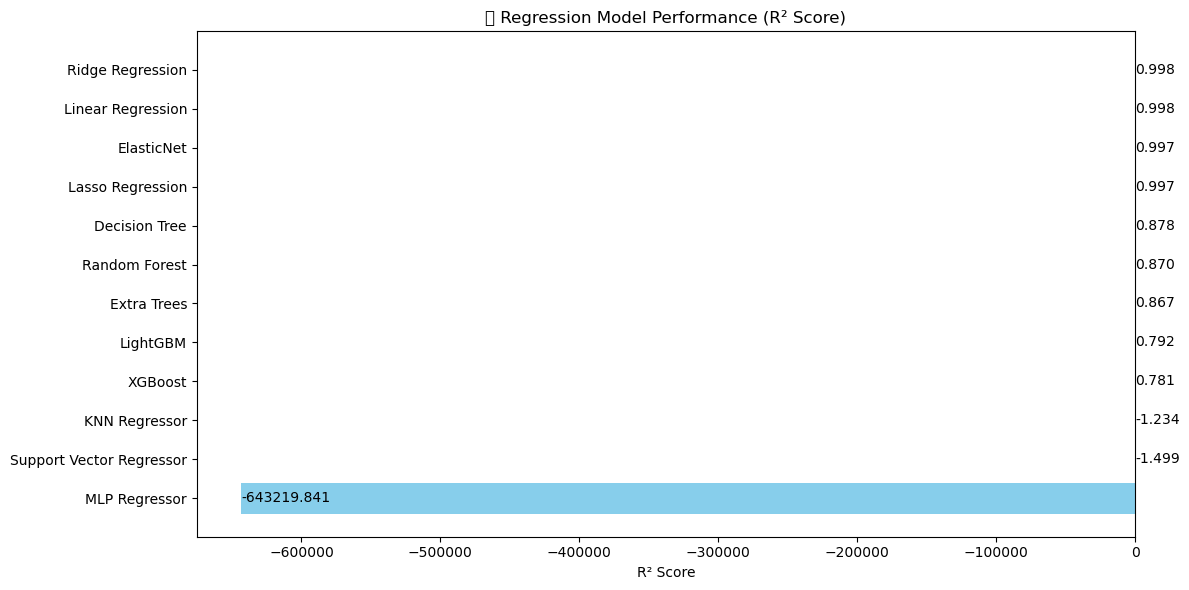

✅ Bar chart saved as 'model_performance_bar_chart.png'


In [148]:
import matplotlib.pyplot as plt

# Set plot size and style
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R2_Score'], color='skyblue')
plt.xlabel('R² Score')
plt.title('📊 Regression Model Performance (R² Score)')
plt.gca().invert_yaxis()  # Highest score on top

# Annotate bars with score values
for i, v in enumerate(results_df['R2_Score']):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')

plt.tight_layout()

# Save the chart as a PNG file
plt.savefig("model_performance_bar_chart.png", dpi=300)

# Display the plot
plt.show()

print("✅ Bar chart saved as 'model_performance_bar_chart.png'")


In [150]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LinearRegression, ElasticNet, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define top 4 models with StandardScaler in a pipeline
scaled_models = {
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ]),
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet())
    ]),
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso())
    ])
}

# Train and evaluate
scaled_results = []

for name, pipeline in scaled_models.items():
    print(f"🔄 Training (with scaling): {name}")
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    scaled_results.append((name, mae, rmse, r2))

# Convert to DataFrame
scaled_results_df = pd.DataFrame(scaled_results, columns=['Model', 'MAE', 'RMSE', 'R2_Score'])
scaled_results_df = scaled_results_df.sort_values(by='R2_Score', ascending=False)

# Display results
print("\n📊 Scaled Model Performance Summary:")
print(scaled_results_df)


🔄 Training (with scaling): Ridge Regression
🔄 Training (with scaling): Linear Regression
🔄 Training (with scaling): ElasticNet
🔄 Training (with scaling): Lasso Regression

📊 Scaled Model Performance Summary:
               Model        MAE       RMSE  R2_Score
0   Ridge Regression   3.806253   7.570174  0.997529
1  Linear Regression   3.827742   7.610103  0.997503
3   Lasso Regression   5.550367   9.371915  0.996213
2         ElasticNet  14.056782  22.025920  0.979084


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.004e+04, tolerance: 1.252e+04
  model = cd_fast.enet_coordinate_descent(


In [152]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import numpy as np
import pandas as pd

# Define models and their hyperparameter grids
models_params = {
    "Ridge Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge())
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    },
    "Lasso Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", Lasso(max_iter=10000))
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    },
    "ElasticNet": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", ElasticNet(max_iter=10000))
        ]),
        "params": {
            "model__alpha": [0.01, 0.1, 1, 10],
            "model__l1_ratio": [0.2, 0.5, 0.8]
        }
    },
    "Linear Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        "params": {}  # No hyperparameters to tune
    }
}

# Store tuning results
best_models = []

# Loop through each model and perform GridSearchCV
for name, config in models_params.items():
    print(f"🔍 Tuning: {name}")
    grid = GridSearchCV(config["pipeline"], config["params"], cv=5, scoring='r2')
    grid.fit(X_train, y_train)
    
    preds = grid.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    best_models.append({
        "Model": name,
        "Best Estimator": grid.best_estimator_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

# Create summary DataFrame
results_df = pd.DataFrame([
    (m["Model"], m["R2"], m["MAE"], m["RMSE"])
    for m in best_models
], columns=["Model", "R2_Score", "MAE", "RMSE"]).sort_values(by="R2_Score", ascending=False)

print("\n🏆 Tuned Model Performance Summary:")
print(results_df)

# Save the best model
best_model = max(best_models, key=lambda m: m["R2"])
with open("best_regression_model.pkl", "wb") as f:
    pickle.dump(best_model["Best Estimator"], f)

print(f"\n✅ Best model '{best_model['Model']}' saved as 'best_regression_model.pkl'")


🔍 Tuning: Ridge Regression
🔍 Tuning: Lasso Regression
🔍 Tuning: ElasticNet
🔍 Tuning: Linear Regression

🏆 Tuned Model Performance Summary:
               Model  R2_Score       MAE      RMSE
1   Lasso Regression  0.997532  3.833797  7.565583
0   Ridge Regression  0.997529  3.806253  7.570174
3  Linear Regression  0.997503  3.827742  7.610103
2         ElasticNet  0.997109  4.297356  8.188423

✅ Best model 'Lasso Regression' saved as 'best_regression_model.pkl'



📊 Model Evaluation Metrics:
MAE  : 3.8338
RMSE : 7.5656
R²   : 0.9975


C:\Users\HP\AppData\Local\Temp\ipykernel_20840\3130464625.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20840\3130464625.py:36: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.savefig("actual_vs_predicted_prices.png", dpi=300)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


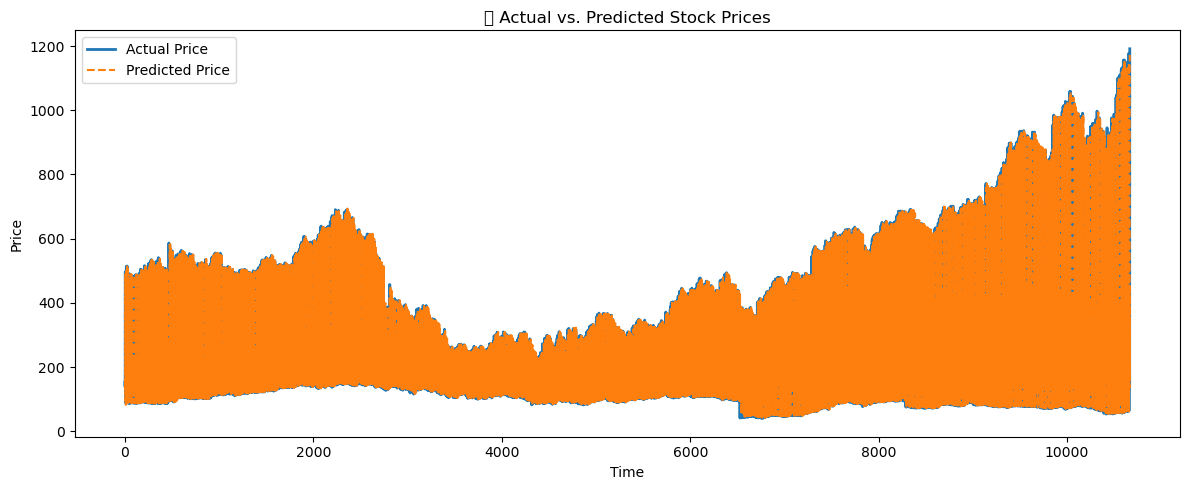

C:\Users\HP\AppData\Local\Temp\ipykernel_20840\3130464625.py:50: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_20840\3130464625.py:51: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.savefig("prediction_error_plot.png", dpi=300)
C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


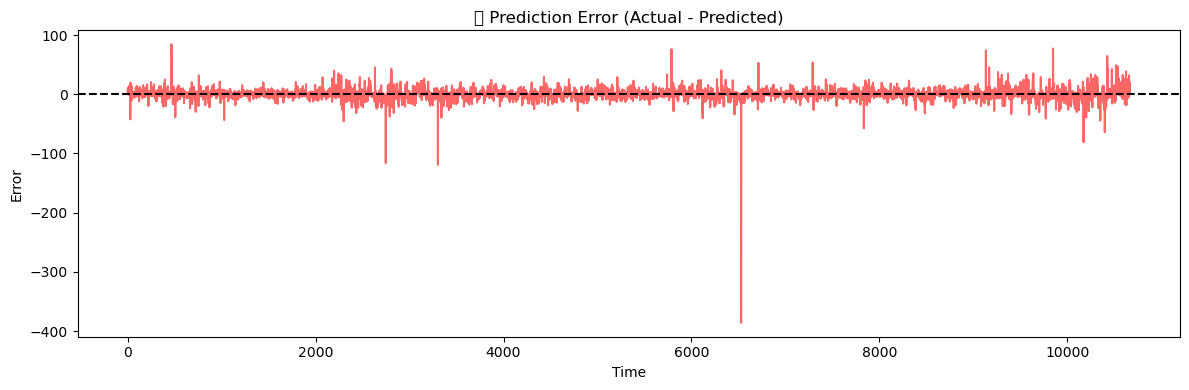

✅ Plots saved as 'actual_vs_predicted_prices.png' and 'prediction_error_plot.png'


In [154]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pickle

# Load the best saved model (optional if already in memory)
with open("best_regression_model.pkl", "rb") as f:
    best_model = pickle.load(f)

# Make predictions on test set
y_pred = best_model.predict(X_test)

# -------------------------------
# 1️⃣ Evaluation Metrics
# -------------------------------
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Model Evaluation Metrics:")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# -------------------------------
# 2️⃣ Plot: Actual vs. Predicted
# -------------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', linewidth=2)
plt.plot(y_pred, label='Predicted Price', linestyle='--')
plt.title('📈 Actual vs. Predicted Stock Prices')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted_prices.png", dpi=300)
plt.show()

# -------------------------------
# 3️⃣ Plot: Prediction Error Over Time
# -------------------------------
errors = y_test.values - y_pred

plt.figure(figsize=(12, 4))
plt.plot(errors, color='red', alpha=0.6)
plt.title('📉 Prediction Error (Actual - Predicted)')
plt.xlabel('Time')
plt.ylabel('Error')
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig("prediction_error_plot.png", dpi=300)
plt.show()

print("✅ Plots saved as 'actual_vs_predicted_prices.png' and 'prediction_error_plot.png'")


In [5]:
open("README.md", "w", encoding="utf-8").write("# 📈 StockPrice_Prediction_AI\n\n> _Forecasting market moves with data-driven precision._\n\n**Intelligent Forecasting of Stock Market Prices Using Regression Machine Learning Models**\n\n## 🔍 Project Overview\nPredict next-day stock prices using regression models trained on historical data from top 10 companies.\n\n## 📁 Repo Structure\n- `Data/` - Raw and processed datasets\n- `Models/` - Saved model files\n- `Output/` - Evaluation plots and logs\n- `Notebook/` - Jupyter notebooks\n- `Deployment/` - API/web app scripts\n\n## ⚙️ Model Pipeline\n- Lag features, rolling stats, RSI, MACD\n- StandardScaler + Ridge, Lasso, ElasticNet\n- Evaluation: MAE, RMSE, R²\n\n## 📈 Best Model\n- Ridge Regression (R² ~ 0.9975)\n- Saved as `best_regression_model.pkl`\n\n## ✅ How to Run\n1. Install deps: `pip install -r requirements.txt`\n2. Run training: `python model_train.py`\n3. Deploy: `streamlit run app.py`\n\n## 👤 Author\nYour Name · [GitHub](https://github.com/your-username)")


945